Conectando a la NOAA para Receta Base Snow/Ice RGB (2026-06-25 18:00:00 UTC)...
Cargando desde disco...
Aplicando receta física base (Nieve en color Cian)...
¡Producto base en Cian generado con éxito!: /Users/diegoperales/Meteorology/GOES/procesados/GOES19_SnowCloud_SENAMHI_Bolivia_CyanBase_20260625_1805.png


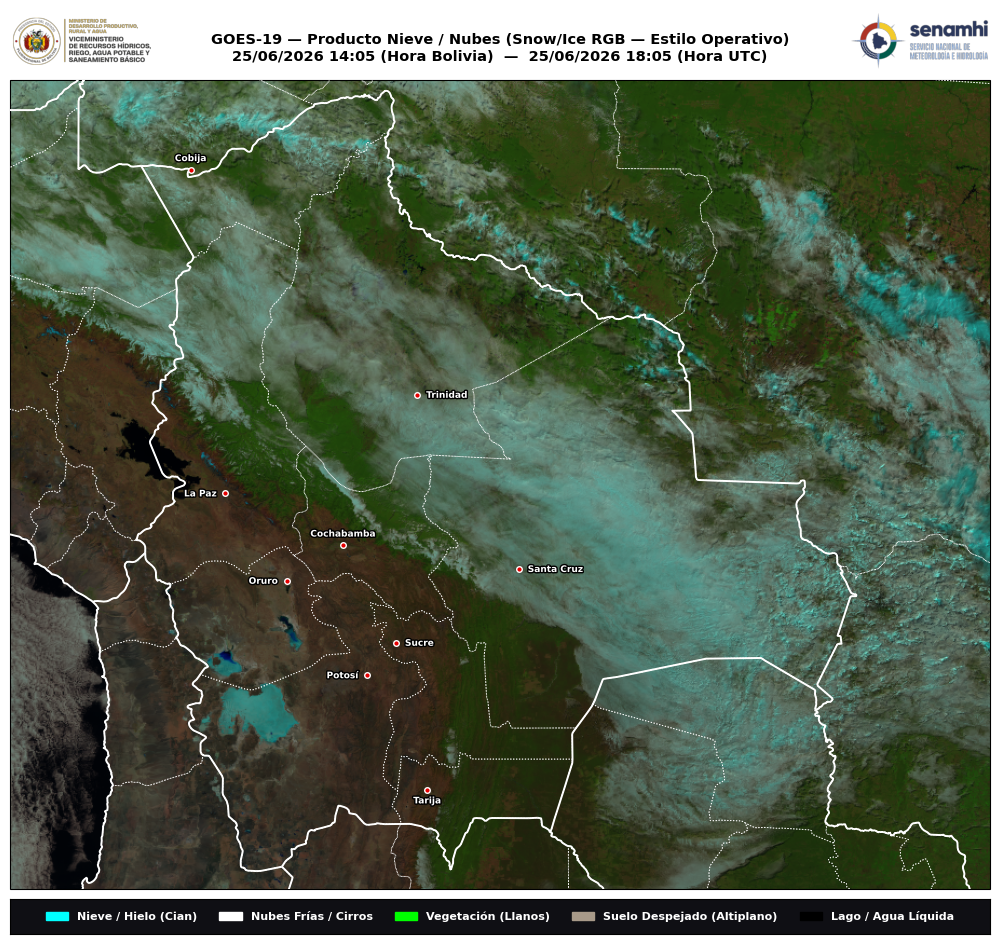

In [15]:
import os
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as patheffects
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import s3fs

# ==========================================
# 1. CONFIGURACIÓN DEL USUARIO
# ==========================================
FECHA_BUSCADA = datetime(2026, 6, 25, 18, 00) 

BASE_DIR = "/Users/diegoperales/Meteorology/GOES"
RAW_DATA = os.path.join(BASE_DIR, "raw_data")
OUTPUTS = os.path.join(BASE_DIR, "procesados")
os.makedirs(RAW_DATA, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

# ==========================================
# 2. CONEXIÓN A AMAZON S3
# ==========================================
print(f"Conectando a la NOAA para Receta Base Snow/Ice RGB ({FECHA_BUSCADA} UTC)...")
fs = s3fs.S3FileSystem(anon=True)

doy = FECHA_BUSCADA.strftime('%j') 
anio = FECHA_BUSCADA.strftime('%Y')
hora = FECHA_BUSCADA.strftime('%H')

s3_folder = f"noaa-goes19/ABI-L2-MCMIPF/{anio}/{doy}/{hora}/"

try:
    archivos = fs.ls(s3_folder)
    archivos_multi = [f for f in archivos if f.endswith('.nc')]
    
    if not archivos_multi:
        print(f"⚠️ Alerta: No hay datos en la hora {hora}. Intentando buscar un bloque antes...")
        hora_alterna = f"{int(hora)-1:02d}"
        s3_folder = f"noaa-goes19/ABI-L2-MCMIPF/{anio}/{doy}/{hora_alterna}/"
        archivos = fs.ls(s3_folder)
        archivos_multi = [f for f in archivos if f.endswith('.nc')]
        
    s3_path = archivos_multi[0]
    file_name = s3_path.split('/')[-1]
    local_path = os.path.join(RAW_DATA, file_name)
    
    if not os.path.exists(local_path):
        print(f"Descargando archivo multibanda: {file_name}...")
        fs.get(s3_path, local_path)
    else:
        print("Cargando desde disco...")
        
    ds = xr.open_dataset(local_path)

except Exception as e:
    print(f"Error crítico: {e}")
    raise e

# ==========================================
# 3. PROYECCIÓN SATELITAL
# ==========================================
glob_attrs = ds.goes_imager_projection.attrs
height = glob_attrs['perspective_point_height']
lon_0 = glob_attrs['longitude_of_projection_origin']
sweep = glob_attrs['sweep_angle_axis']

dataprojenv = ccrs.Geostationary(central_longitude=lon_0, satellite_height=height, sweep_axis=sweep)

# ==========================================
# 4. RECETA ESPECTRAL BASE: SNOW/ICE CIAN RGB
# ==========================================
print("Aplicando receta física base (Nieve en color Cian)...")

# Extracción de bandas reflectivas calibradas
b2 = ds['CMI_C02'].data  # 0.64 um (Visible)
b3 = ds['CMI_C03'].data  # 0.86 um (NIR)
b5 = ds['CMI_C05'].data  # 1.61 um (SWIR)

# Normalización básica estricta [0, 1]
# Tradicionalmente: R = Banda 5, G = Banda 3, B = Banda 2
R = np.clip(b5 / 1.0, 0, 1)
G = np.clip(b3 / 1.0, 0, 1)
B = np.clip(b2 / 1.0, 0, 1)

# Aplicación de curvas gamma estándar para realzar contraste en el visible
R = np.power(R, 1.0)
G = np.power(G, 1.0)
B = np.power(B, 1.0)

rgb_image = np.dstack((R, G, B))

# ==========================================
# 5. GENERACIÓN DEL PRODUCTO VISUAL
# ==========================================
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white', subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(left=0.01, right=0.99, top=0.88, bottom=0.06)

ax.set_extent([-71.8, -55.2, -23.2, -9.5], crs=ccrs.PlateCarree())

x = ds.x.data * height
y = ds.y.data * height

# --- CAPA 1: IMAGEN SATELITAL ---
ax.imshow(rgb_image, origin='upper', transform=dataprojenv, extent=[x.min(), x.max(), y.min(), y.max()], zorder=1)

# --- CAPA 2: LÍMITES GEOGRÁFICOS ---
COLOR_BLANCO = '#ffffff'
ax.add_feature(cfeature.COASTLINE, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.STATES, linestyle=(0, (1, 2)), edgecolor=COLOR_BLANCO, linewidth=0.7, zorder=4)

# --- CAPA 3: CAPITALES DE BOLIVIA ---
capitales = {
    "Cobija":        {"lat": -11.02, "lon": -68.74, "pos": "top"},
    "Trinidad":      {"lat": -14.83, "lon": -64.90, "pos": "right"},
    "La Paz":        {"lat": -16.50, "lon": -68.15, "pos": "left"},
    "Cochabamba":    {"lat": -17.38, "lon": -66.16, "pos": "top"},
    "Santa Cruz":    {"lat": -17.78, "lon": -63.18, "pos": "right"},
    "Oruro":         {"lat": -17.98, "lon": -67.11, "pos": "left"},
    "Sucre":         {"lat": -19.03, "lon": -65.26, "pos": "right"},
    "Potosí":        {"lat": -19.58, "lon": -65.75, "pos": "left"},
    "Tarija":        {"lat": -21.53, "lon": -64.73, "pos": "bottom"}
}

for ciudad, info in capitales.items():
    ax.plot(info["lon"], info["lat"], marker='o', color='#E50001', markersize=4, markeredgecolor='white', markeredgewidth=1.0, transform=ccrs.PlateCarree(), zorder=10)
    offset_lon = 0.15 if info["pos"] == "right" else (-0.15 if info["pos"] == "left" else 0)
    offset_lat = 0.15 if info["pos"] == "top" else (-0.22 if info["pos"] == "bottom" else -0.05)
    alignment_h = "left" if info["pos"] == "right" else ("right" if info["pos"] == "left" else "center")
    
    ax.text(info["lon"] + offset_lon, info["lat"] + offset_lat, ciudad, color='white', fontsize=6.5, fontweight='bold', horizontalalignment=alignment_h, transform=ccrs.PlateCarree(), zorder=11, path_effects=[patheffects.withStroke(linewidth=2, foreground='black')])

# --- CAPA 4: PROCESAMIENTO DE FECHAS ---
fecha_utc = datetime.strptime(ds.t.dt.strftime('%Y-%m-%d %H:%M').item(), '%Y-%m-%d %H:%M')
fecha_bot = fecha_utc - timedelta(hours=4)
string_utc = fecha_utc.strftime('%d/%m/%Y %H:%M (Hora UTC)')
string_bot = fecha_bot.strftime('%d/%m/%Y %H:%M (Hora Bolivia)')

# --- CAPA 5: TÍTULO CORPORATIVO ---
ax.set_title(f"GOES-19 — Producto Nieve / Nubes (Snow/Ice RGB — Estilo Operativo)\n{string_bot}  —  {string_utc}", fontsize=10.5, fontweight='bold', pad=14, loc='center', linespacing=1.3)

# --- CAPA 6: LEYENDA CORPORATIVA ---
pos_mapa = ax.get_position()
ax_leyenda = fig.add_axes([pos_mapa.x0, pos_mapa.y0 - 0.045, pos_mapa.width, 0.035])
ax_leyenda.set_facecolor('#0f0f14')
ax_leyenda.set_xticks([])
ax_leyenda.set_yticks([])

parches_leyenda = [
    mpatches.Patch(color='#00ffff', label='Nieve / Hielo (Cian)'), 
    mpatches.Patch(color='#ffffff', label='Nubes Frías / Cirros'),
    mpatches.Patch(color='#00ff00', label='Vegetación (Llanos)'),
    mpatches.Patch(color='#a89a89', label='Suelo Despejado (Altiplano)'),
    mpatches.Patch(color='#000000', label='Lago / Agua Líquida')
]

leyenda = ax_leyenda.legend(handles=parches_leyenda, loc='center', ncol=5, frameon=False, fontsize=8.0)

for text in leyenda.get_texts():
    text.set_color('white')
    text.set_weight('bold')

# --- CAPA 7: INSERCIÓN DE LOGOS ---
PATH_LOGOS = os.path.join(BASE_DIR, "logos")
try:
    img_ministerio_path = os.path.join(PATH_LOGOS, "logo_ministerio.png")
    img_senamhi_path = os.path.join(PATH_LOGOS, "logo_senamhi.png")
    
    if os.path.exists(img_ministerio_path) and os.path.exists(img_senamhi_path):
        logo_ministerio = mpimg.imread(img_ministerio_path)
        logo_senamhi = mpimg.imread(img_senamhi_path)
        
        ax_logo_min = fig.add_axes([pos_mapa.x0, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_min.imshow(logo_ministerio)
        ax_logo_min.axis('off')
        
        ax_logo_sen = fig.add_axes([pos_mapa.x1 - 0.14, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_sen.imshow(logo_senamhi)
        ax_logo_sen.axis('off')
except Exception as e:
    print(f"Alerta logos: {e}")

output_name = f"{OUTPUTS}/GOES19_SnowCloud_SENAMHI_Bolivia_CyanBase_{fecha_utc.strftime('%Y%m%d_%H%M')}.png"
plt.savefig(output_name, dpi=200, bbox_inches='tight', pad_inches=0.04)
print(f"¡Producto base en Cian generado con éxito!: {output_name}")

plt.show()